Rows: 10000
Missing Values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64
Duplicates: 0

Failure Distribution:
Target
0    9661
1     339
Name: count, dtype: int64


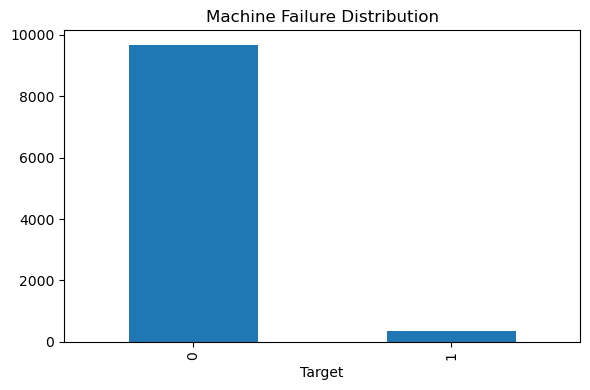

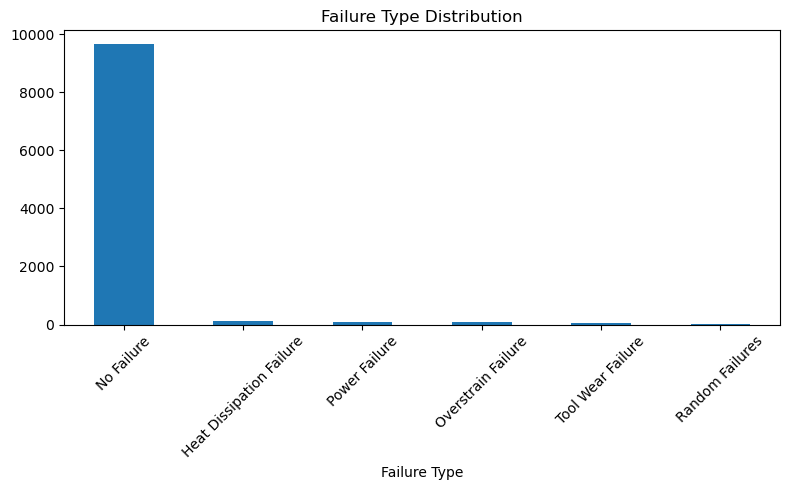

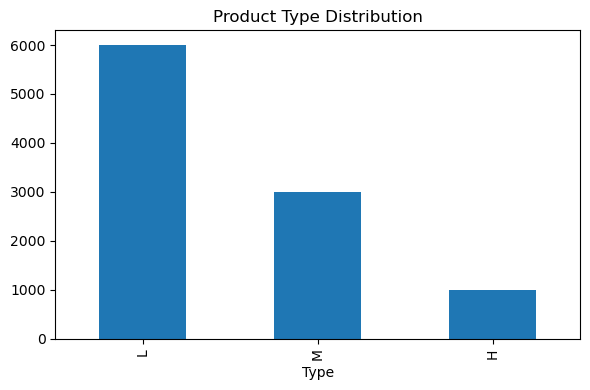

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_csv("predictive_maintenance.csv")

conn = sqlite3.connect("maintenance.db")
df.to_sql("predictive_maintenance", conn, if_exists="replace", index=False)

df = pd.read_sql("""
SELECT DISTINCT *
FROM predictive_maintenance
WHERE UDI IS NOT NULL
""", conn)

print("Rows:", len(df))
print("Missing Values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

print("\nFailure Distribution:")
print(df["Target"].value_counts())

plt.figure(figsize=(6,4))
df["Target"].value_counts().plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
df["Failure Type"].value_counts().plot(kind="bar")
plt.title("Failure Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df["Type"].value_counts().plot(kind="bar")
plt.title("Product Type Distribution")
plt.tight_layout()
plt.show()

conn.close()